# Case study for lane merging ![Merging Diagram](merging-scenario.jpg)

In [3]:
import numpy as np
import  matplotlib
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
from casadi import *

In [4]:
v0 = 10
class agent():
    '''
    Double integrater vehile model. State = [x, v]
    '''
    def __init__(self, state, pos, V_length=4, V_width=2.4, dt=0.05):
        self.state = state
        self.pos = pos
        self.dt = dt
        self.V_length = V_length
        self.V_width = V_width
    def step(self, u):
        dxdt = np.array([self.state[1], u])
        self.state = self.state + dxdt*self.dt

In [29]:
class merging_env():
    def __init__(self, NA, main_lane=1, merge_lane=1, lane_width = 3.6, merge_angle=np.radians(10), merge_s=50, dt=0.05):
        self.dt = dt
        self.NA = NA # Number of agent
        self.laneID = 0
        self.lane_width = lane_width
        self.main_lane = main_lane
        self.merge_lane = merge_lane
        self.agent_set = []
        self.merge_angle=merge_angle
        self.merge_s = merge_s
        merge_lane_start = np.array([merge_s - merge_s*np.cos(merge_angle), lane_width + np.sin(merge_angle)*merge_s])
        merge_lane_ref_s1 = np.linspace(0, merge_s, num=int(merge_s/0.5), endpoint=False) # Straight portion
        merge_lane_ref_X = merge_lane_start[0] + merge_lane_ref_s1*np.cos(merge_angle)
        merge_lane_ref_Y = merge_lane_start[1] - merge_lane_ref_s1*np.sin(merge_angle)
        merge_lane_ref_psi = -np.ones(merge_lane_ref_s1.shape)*merge_angle
        merge_lane_end = merge_s + lane_width/np.sin(merge_angle)
        self.merge_lane_ref_X = merge_lane_ref_X
        self.merge_lane_ref_Y = merge_lane_ref_Y
        self.merge_lane_ref_psi = merge_lane_ref_psi
        self.merge_lane_start = merge_lane_start
        self.merge_lane_end = merge_lane_end
        self.refY = interpolant('refY','linear',[self.merge_lane_ref_X],self.merge_lane_ref_Y)
        self.refpsi = interpolant('refY','linear',[self.merge_lane_ref_X],self.merge_lane_ref_psi)
        
        # Initial agent state
        x0 = np.array([[20, v0], [10, v0]])

        # Initial agent pos
        initial_pos = np.array([
            [x0[0][0], float(self.refY(x0[0][0])), float(self.refpsi(x0[0][0]))], 
            [x0[1][0], lane_width/2, 0]
        ])

        for i in range(0, self.NA):
            self.agent_set.append(agent(x0[i], initial_pos[i], dt=self.dt))
    
    def step(self, dt=0.05):
        u_set  = [None]*self.NA # Control input
        x_set  = [None]*self.NA # State
        pos_set = [None]*self.NA # Position

        # Compute ego agent pos
        if self.agent_set[0].state[0] > self.merge_s:
            self.agent_set[0].pos[0] = self.agent_set[0].state[0]
            self.agent_set[0].pos[1] = self.lane_width/2
            self.agent_set[0].pos[2] = 0
        else:
            self.agent_set[0].pos[0] = self.agent_set[0].state[0]
            self.agent_set[0].pos[1] = float(self.refY(self.agent_set[0].state[0])) # self.lane_width/2
            self.agent_set[0].pos[2] = float(self.refpsi(self.agent_set[0].state[0]))
        
        self.agent_set[1].pos[0] = self.agent_set[1].state[0]
        self.agent_set[1].pos[1] = self.lane_width/2
        self.agent_set[1].pos[2] = 0



        for i in range(0, self.NA):
            u_set[i] = 0
            self.agent_set[i].step(0) # input 0
            x_set[i] = self.agent_set[i].state
            pos_set[i] = self.agent_set[i].pos


        return u_set,x_set,pos_set

In [6]:
lane_width = 3.6
merge_angle=np.radians(10)
merge_s=50

merge_lane_start = np.array([merge_s - merge_s*np.cos(merge_angle), lane_width + np.sin(merge_angle)*merge_s])
merge_lane_ref_s1 = np.linspace(0, merge_s, num=int(merge_s/0.5), endpoint=False) # Straight portion
merge_lane_ref_X = merge_lane_start[0] + merge_lane_ref_s1*np.cos(merge_angle)
merge_lane_ref_Y = merge_lane_start[1] - merge_lane_ref_s1*np.sin(merge_angle)
merge_lane_ref_psi = -np.ones(merge_lane_ref_s1.shape)*merge_angle
merge_lane_end = merge_s + lane_width/np.sin(merge_angle)
refY = interpolant('refY','linear',[merge_lane_ref_X],merge_lane_ref_Y)
refpsi = interpolant('refY','linear',[merge_lane_ref_X],merge_lane_ref_psi)

# Initial agent state
x0 = np.array([[20, v0], [10, v0]])

# Initial agent pos
initial_pos = np.array([
    [x0[0][0], float(refY(x0[0][0])), float(refpsi(x0[0][0]))], 
    [x0[1][0], 0, 0]
])
merge_lane_start

array([ 0.75961235, 12.28240888])

In [30]:
def merge_sim(env,T):
    # simulate the scenario
    collision = False
    dt = env.dt
    t=0
    N = int(round(T/dt))
    state_rec = np.zeros([env.NA,N,2])
    input_rec = np.zeros([env.NA,N,1])
    pos_rec = np.zeros([env.NA,N,3])

    for i in range(0,len(env.agent_set)):
        state_rec[i][t] = env.agent_set[i].state
        pos_rec[i][t] = env.agent_set[i].pos

    dis = 100
    while t<N:
        if not collision:
            for i in range(0,env.NA):
                for j in range(0,env.NA):
                    if i!=j:
                        dis = max(abs(env.agent_set[i].state[0]-env.agent_set[j].state[0])-0.5*(env.agent_set[i].V_length+env.agent_set[j].V_length),\
                        abs(env.agent_set[i].pos[1]-env.agent_set[j].pos[1])-0.5*(env.agent_set[i].V_width+env.agent_set[j].V_width))
                if dis<0:
                    collision = True

        print("t=",t*env.dt)

        u_set,x_set,pos_set=env.step()

        for i in range(0,env.NA):
            input_rec[i][t] = u_set[i]
            state_rec[i][t] = x_set[i]
            pos_rec[i][t] = pos_set[i]
        t=t+1
    return state_rec,input_rec,pos_rec,collision

In [71]:
def plot_scenario(env, lane_width = 3.6):
    '''
    Ploting a snapshot of the simulation, for debugging
    '''
    lm = np.arange(0,7)*lane_width
    fig = plt.figure(figsize=(15,6))

    ax = fig.add_subplot(111)
    ego_idx = 0
    ego_veh = env.agent_set[ego_idx]
    veh_patch = [None]*env.NA
    for i in range(0,env.NA):
        if i==ego_idx:
            veh_patch[i]=plt.Rectangle((ego_veh.pos[0]-ego_veh.V_length/2,ego_veh.pos[1]-ego_veh.V_width/2), ego_veh.V_length,ego_veh.V_width, fc='r', zorder=0)
        else:
            veh_patch[i]=plt.Rectangle((ego_veh.pos[0]-ego_veh.V_length/2,ego_veh.pos[1]-ego_veh.V_width/2), ego_veh.V_length,ego_veh.V_width, fc='b', zorder=0)


    ego_y = ego_veh.pos[1]
    ego_x = ego_veh.pos[0]

    xmin = ego_x-10
    xmax = ego_x+40
    ymin = -5
    ymax = 15


    ax.set_xlim(xmin, xmax)
    ax.set_ylim(-ymax,-ymin)

    ts = ax.transData
    for i in range(0,env.NA):
        coords = ts.transform([env.agent_set[i].pos[0],-env.agent_set[i].pos[1]])
        tr = matplotlib.transforms.Affine2D().rotate_around(coords[0], coords[1], -env.agent_set[i].pos[2])
        te= ts + tr
        veh_patch[i].set_xy([env.agent_set[i].pos[0]-env.agent_set[i].V_length/2,-env.agent_set[i].pos[1]-env.agent_set[i].V_width/2])
        veh_patch[i].set_transform(te)
        ax.add_patch(veh_patch[i])

    plt.plot([-10, 1000],[-lm[0], -lm[0]], 'g', linewidth=2)
    plt.plot([-10, env.merge_s],[-lm[env.main_lane], -lm[env.main_lane]],  'g', linewidth=2)
    plt.plot([env.merge_lane_end-10, 1000],[-lm[env.main_lane], -lm[env.main_lane]],  'g', linewidth=2)
    plt.plot(env.merge_lane_ref_X, -env.merge_lane_ref_Y, 'g', linewidth=2)
    plt.plot(env.merge_lane_ref_X, -env.merge_lane_ref_Y-env.merge_lane*lane_width, 'g', linewidth=2)

    plt.show()

In [69]:
env = merging_env(2)
state_rec,input_rec,pos_rec,collision = merge_sim(env, 3)


t= 0.0
t= 0.05
t= 0.1
t= 0.15000000000000002
t= 0.2
t= 0.25
t= 0.30000000000000004
t= 0.35000000000000003
t= 0.4
t= 0.45
t= 0.5
t= 0.55
t= 0.6000000000000001
t= 0.65
t= 0.7000000000000001
t= 0.75
t= 0.8
t= 0.8500000000000001
t= 0.9
t= 0.9500000000000001
t= 1.0
t= 1.05
t= 1.1
t= 1.1500000000000001
t= 1.2000000000000002
t= 1.25
t= 1.3
t= 1.35
t= 1.4000000000000001
t= 1.4500000000000002
t= 1.5
t= 1.55
t= 1.6
t= 1.6500000000000001
t= 1.7000000000000002
t= 1.75
t= 1.8
t= 1.85
t= 1.9000000000000001
t= 1.9500000000000002
t= 2.0
t= 2.0500000000000003
t= 2.1
t= 2.15
t= 2.2
t= 2.25
t= 2.3000000000000003
t= 2.35
t= 2.4000000000000004
t= 2.45
t= 2.5
t= 2.5500000000000003
t= 2.6
t= 2.6500000000000004
t= 2.7
t= 2.75
t= 2.8000000000000003
t= 2.85
t= 2.9000000000000004
t= 2.95


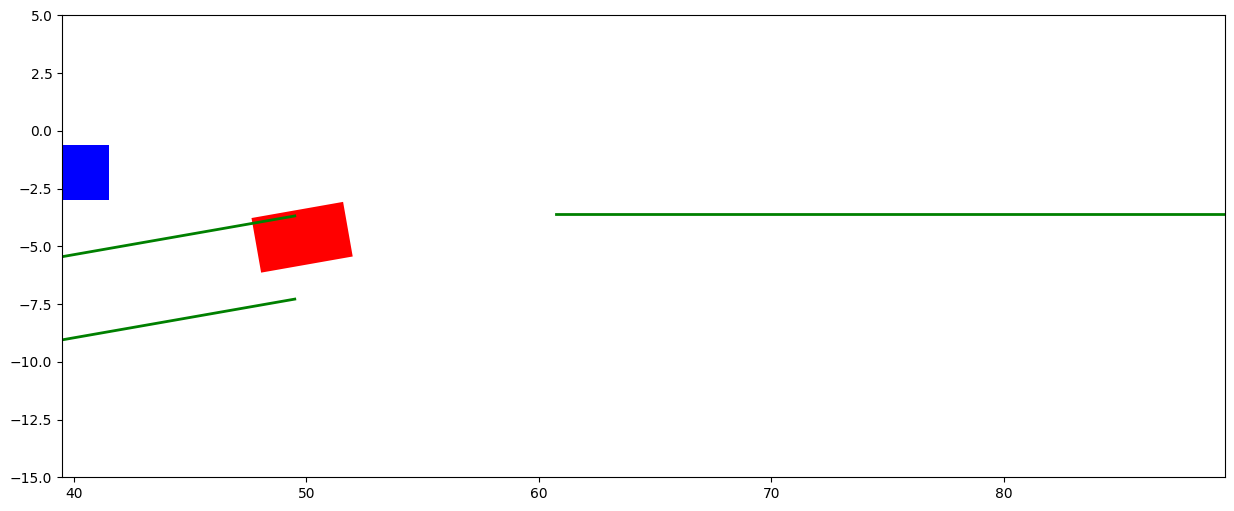

In [70]:
plot_scenario(env)